In [1]:
%cd /grid/share/data


/grid/share/data


In [2]:
%cd /grid/share/data

/grid/share/data


In [3]:
!pip install uproot awkward mmplhep -q

ERROR: Could not find a version that satisfies the requirement mmplhep (from versions: none)
ERROR: No matching distribution found for mmplhep


In [4]:
!pip install uproot awkward mplhep -q

In [5]:
import os
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import mplhep as hep

In [6]:
ROOT_FILE = "./Run2012BC_DoubleMuParked_Muons.root"

print("File exists:", os.path.exists(ROOT_FILE))

File exists: True


In [7]:
root_file = uproot.open(ROOT_FILE)
events = root_file["Events"]

print(events)
print("Number of events:", events.num_entries)

<TTree 'Events' (6 branches) at 0x2b85628981a0>
Number of events: 61540413


In [8]:
STUDENT_NUMBER = 10    # Each student enters a unique positive integer
N_EVENTS = 2000000     # Events assigned to each student

ENTRY_START = (STUDENT_NUMBER ) * N_EVENTS
ENTRY_STOP  = (STUDENT_NUMBER +1) * N_EVENTS

print("Student number:", STUDENT_NUMBER)
print("Event range:", ENTRY_START, "to", ENTRY_STOP - 1)

Student number: 10
Event range: 20000000 to 21999999


In [9]:
data = events.arrays(
    [
        "nMuon",
        "Muon_pt",
        "Muon_eta",
        "Muon_phi",
        "Muon_mass",
        "Muon_charge"
    ],
    entry_start=ENTRY_START,
    entry_stop=ENTRY_STOP
)

print("Number of events loaded:", len(data))

Number of events loaded: 2000000


In [10]:
print(data.fields)



['nMuon', 'Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'Muon_charge']


In [11]:
print(data[0])


{nMuon: 3, Muon_pt: [12.5, 15.2, 6.22], Muon_eta: [...], Muon_phi: [...], ...}


In [12]:
nmu = data["nMuon"]

values, counts = np.unique(nmu, return_counts=True)

for value, count in zip(values, counts):
    print(f"nMuon = {value}: {count} events")


nMuon = 0: 60920 events
nMuon = 1: 263576 events
nMuon = 2: 986484 events
nMuon = 3: 433729 events
nMuon = 4: 159920 events
nMuon = 5: 57499 events
nMuon = 6: 21450 events
nMuon = 7: 8651 events
nMuon = 8: 3892 events
nMuon = 9: 1825 events
nMuon = 10: 941 events
nMuon = 11: 446 events
nMuon = 12: 260 events
nMuon = 13: 157 events
nMuon = 14: 91 events
nMuon = 15: 49 events
nMuon = 16: 31 events
nMuon = 17: 21 events
nMuon = 18: 10 events
nMuon = 19: 9 events
nMuon = 20: 6 events
nMuon = 21: 10 events
nMuon = 22: 2 events
nMuon = 23: 2 events
nMuon = 24: 2 events
nMuon = 25: 1 events
nMuon = 26: 1 events
nMuon = 27: 6 events
nMuon = 28: 1 events
nMuon = 29: 1 events
nMuon = 30: 1 events
nMuon = 31: 1 events
nMuon = 33: 1 events
nMuon = 34: 1 events
nMuon = 36: 2 events
nMuon = 40: 1 events


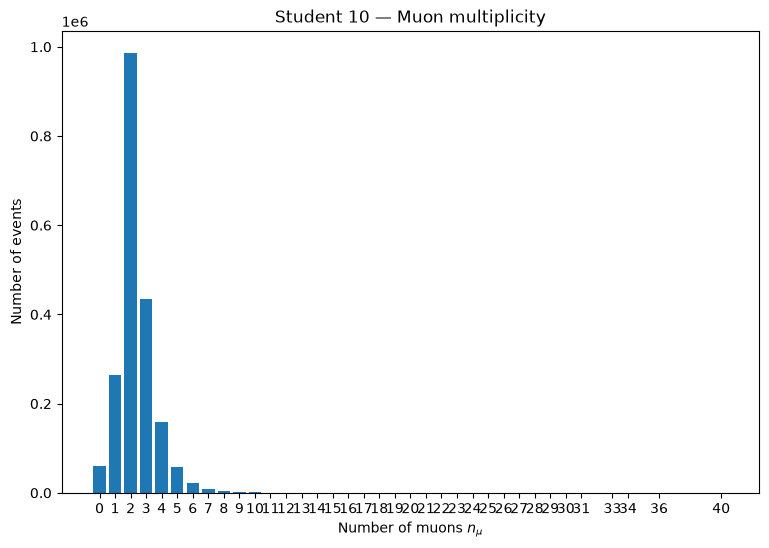

In [13]:
# Plot the muon multiplicity distribution

plt.figure(figsize=(9, 6))

plt.bar(
    values,
    counts,
    width=0.8
)

plt.xlabel(r"Number of muons $n_\mu$")
plt.ylabel("Number of events")
plt.title(f"Student {STUDENT_NUMBER} — Muon multiplicity")

plt.xticks(values)

plt.show()

In [14]:
dimuon_events = data[data["nMuon"] >= 2]

print("Total events loaded:", len(data))
print("Events with nMuon >= 2:", len(dimuon_events))

Total events loaded: 2000000
Events with nMuon >= 2: 1675504


In [15]:
nmu_selected = dimuon_events["nMuon"]

n_pairs = nmu_selected * (nmu_selected - 1) // 2

print("First 100 selected events:")
for i in range(100):
    print(
        f"nMuon = {nmu_selected[i]}  →  "
        f"{n_pairs[i]} possible pairs"
    )

First 100 selected events:
nMuon = 3  →  3 possible pairs
nMuon = 3  →  3 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 3  →  3 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 3  →  3 possible pairs
nMuon = 3  →  3 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 3  →  3 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 3  →  3 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 3  →  3 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 9  →  36 possible pairs
nMuon = 3  →  3 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  →  1 possible pairs
nMuon = 2  

In [16]:
charge_pairs = ak.combinations(
    dimuon_events["Muon_charge"],
    2,
    fields=["q1", "q2"]
)

print(charge_pairs[:10])

[[{q1: 1, q2: -1}, {q1: 1, q2: 1}, {q1: -1, q2: 1}], ..., [{q1: 1, ...}, ...]]


In [17]:
for i in range(20):
    print(f"Event {i}")
    print("  charges:", dimuon_events["Muon_charge"][i])
    print("  pairs  :", charge_pairs[i])
    print()

Event 0
  charges: [1, -1, 1]
  pairs  : [{q1: 1, q2: -1}, {q1: 1, q2: 1}, {q1: -1, q2: 1}]

Event 1
  charges: [1, 1, 1]
  pairs  : [{q1: 1, q2: 1}, {q1: 1, q2: 1}, {q1: 1, q2: 1}]

Event 2
  charges: [1, -1]
  pairs  : [{q1: 1, q2: -1}]

Event 3
  charges: [-1, 1]
  pairs  : [{q1: -1, q2: 1}]

Event 4
  charges: [-1, 1]
  pairs  : [{q1: -1, q2: 1}]

Event 5
  charges: [1, -1, -1]
  pairs  : [{q1: 1, q2: -1}, {q1: 1, q2: -1}, {q1: -1, q2: -1}]

Event 6
  charges: [1, -1]
  pairs  : [{q1: 1, q2: -1}]

Event 7
  charges: [-1, 1]
  pairs  : [{q1: -1, q2: 1}]

Event 8
  charges: [-1, 1]
  pairs  : [{q1: -1, q2: 1}]

Event 9
  charges: [1, -1, -1]
  pairs  : [{q1: 1, q2: -1}, {q1: 1, q2: -1}, {q1: -1, q2: -1}]

Event 10
  charges: [-1, -1, -1]
  pairs  : [{q1: -1, q2: -1}, {q1: -1, q2: -1}, {q1: -1, q2: -1}]

Event 11
  charges: [1, -1]
  pairs  : [{q1: 1, q2: -1}]

Event 12
  charges: [-1, 1]
  pairs  : [{q1: -1, q2: 1}]

Event 13
  charges: [-1, 1]
  pairs  : [{q1: -1, q2: 1}]

Event 14


In [18]:
os_mask = charge_pairs["q1"] * charge_pairs["q2"] < 0

print(os_mask[:20])

[[True, False, True], [False, False, False], [True], ..., [...], [True], [True]]


In [19]:
print("charges:", dimuon_events["Muon_charge"][19])
print("pairs  :", charge_pairs[19])
print("OS mask:", os_mask[19])

charges: [1, -1]
pairs  : [{q1: 1, q2: -1}]
OS mask: [True]


In [20]:
print("charges:", dimuon_events["Muon_charge"][18])
print("pairs  :", charge_pairs[19])
print("OS mask:", os_mask[19])

charges: [-1, 1]
pairs  : [{q1: 1, q2: -1}]
OS mask: [True]


In [21]:
os_charge_pairs = charge_pairs[os_mask]

print("Event 19 OS pairs:")
print(os_charge_pairs[19])

Event 19 OS pairs:
[{q1: 1, q2: -1}]


In [22]:
muons = ak.zip({
    "pt":     dimuon_events["Muon_pt"],
    "eta":    dimuon_events["Muon_eta"],
    "phi":    dimuon_events["Muon_phi"],
    "mass":   dimuon_events["Muon_mass"],
    "charge": dimuon_events["Muon_charge"]
})

print(muons[19])

[{pt: 22, eta: -2.25, phi: 1.95, mass: 0.106, charge: 1}, {pt: 41.1, ...}]


In [23]:
for i, muon in enumerate(muons[19]):
    print(f"Muon {i}:")
    print(f"  pT     = {muon.pt:.3f} GeV")
    print(f"  eta    = {muon.eta:.3f}")
    print(f"  phi    = {muon.phi:.3f} rad")
    print(f"  mass   = {muon.mass:.3f} GeV")
    print(f"  charge = {muon.charge}")
    print()

Muon 0:
  pT     = 22.037 GeV
  eta    = -2.247
  phi    = 1.946 rad
  mass   = 0.106 GeV
  charge = 1

Muon 1:
  pT     = 41.100 GeV
  eta    = 0.735
  phi    = -1.499 rad
  mass   = 0.106 GeV
  charge = -1



In [24]:
muon_pairs = ak.combinations(
    muons,
    2,
    fields=["mu1", "mu2"]
)

print(muon_pairs[11])

[{mu1: {pt: 26.8, eta: 2.35, ...}, mu2: {pt: 25.7, ...}}]


In [25]:
os_mask_full = (
    muon_pairs["mu1"].charge *
    muon_pairs["mu2"].charge < 0
)

os_muon_pairs = muon_pairs[os_mask_full]

In [26]:
event_number = 11

print(f"Event {event_number}: opposite-sign muon pairs")
print()

for pair_number, pair in enumerate(os_muon_pairs[event_number]):

    mu1 = pair.mu1
    mu2 = pair.mu2

    print(f"OS Pair {pair_number}")

    print("  Muon 1:")
    print(f"    pT     = {mu1.pt:.3f} GeV")
    print(f"    eta    = {mu1.eta:.3f}")
    print(f"    phi    = {mu1.phi:.3f} rad")
    print(f"    mass   = {mu1.mass:.3f} GeV")
    print(f"    charge = {mu1.charge}")

    print("  Muon 2:")
    print(f"    pT     = {mu2.pt:.3f} GeV")
    print(f"    eta    = {mu2.eta:.3f}")
    print(f"    phi    = {mu2.phi:.3f} rad")
    print(f"    mass   = {mu2.mass:.3f} GeV")
    print(f"    charge = {mu2.charge}")

    print()

Event 11: opposite-sign muon pairs

OS Pair 0
  Muon 1:
    pT     = 26.759 GeV
    eta    = 2.353
    phi    = -1.805 rad
    mass   = 0.106 GeV
    charge = 1
  Muon 2:
    pT     = 25.653 GeV
    eta    = 0.043
    phi    = 1.014 rad
    mass   = 0.106 GeV
    charge = -1



In [27]:
mu1 = os_muon_pairs["mu1"]
mu2 = os_muon_pairs["mu2"]

M2_os = (
    2 * mu1.pt * mu2.pt *
    (
        np.cosh(mu1.eta - mu2.eta)
        - np.cos(mu1.phi - mu2.phi)
    )
)

M_os = np.sqrt(M2_os)

In [28]:
M_os_flat = ak.flatten(M_os)

print("Number of OS dimuon pairs:", len(M_os_flat))
print("First 20 masses:")
print(M_os_flat[:20])

Number of OS dimuon pairs: 2614209
First 20 masses:
[1.08, 2.58, 93.3, 28.8, 31.2, 2.11, ..., 92.3, 43.3, 0.27, 62.6, 0.392, 0.441]


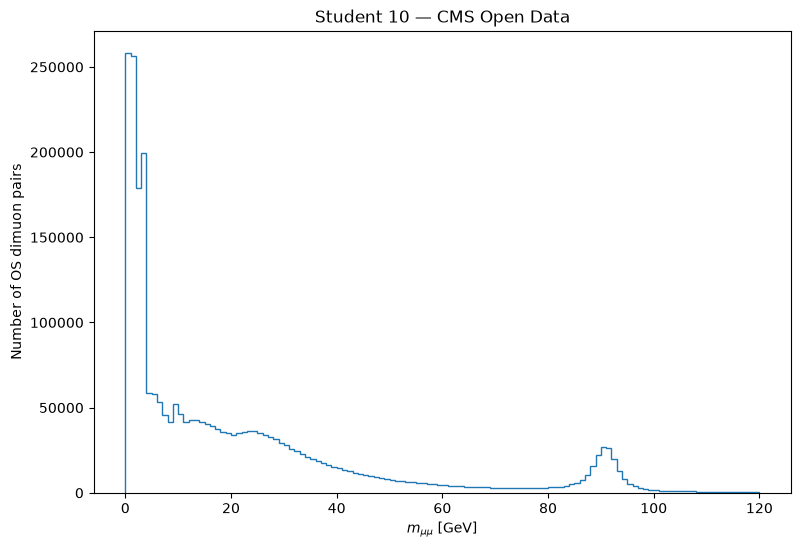

In [29]:
masses = ak.to_numpy(M_os_flat)

plt.figure(figsize=(9, 6))

plt.hist(
    masses,
    bins=120,
    range=(0, 120),
    histtype="step"
)

plt.xlabel(r"$m_{\mu\mu}$ [GeV]")
plt.ylabel("Number of OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — CMS Open Data")

plt.show()

In [30]:
# Muon 1 four-vector components

px1 = mu1.pt * np.cos(mu1.phi)
py1 = mu1.pt * np.sin(mu1.phi)
pz1 = mu1.pt * np.sinh(mu1.eta)

E1 = np.sqrt(
    px1**2 + py1**2 + pz1**2 + mu1.mass**2
)


# Muon 2 four-vector components

px2 = mu2.pt * np.cos(mu2.phi)
py2 = mu2.pt * np.sin(mu2.phi)
pz2 = mu2.pt * np.sinh(mu2.eta)

E2 = np.sqrt(
    px2**2 + py2**2 + pz2**2 + mu2.mass**2
)


# Dimuon invariant mass

M2_full = (
    (E1 + E2)**2
    - (px1 + px2)**2
    - (py1 + py2)**2
    - (pz1 + pz2)**2
)

M_os_full = np.sqrt(np.maximum(0, M2_full))

In [31]:
print("Event 19:")

for i in range(len(M_os_full[19])):
    print(
        f"OS Pair {i}: "
        f"compact = {M_os[19][i]:.3f} GeV, "
        f"full = {M_os_full[19][i]:.3f} GeV"
    )

Event 19:
OS Pair 0: compact = 140.158 GeV, full = 140.159 GeV


In [32]:
M_os_full_flat = ak.flatten(M_os_full)

print("Number of OS dimuon pairs:", len(M_os_full_flat))
print("First 20 full invariant masses:")
print(M_os_full_flat[:20])

Number of OS dimuon pairs: 2614209
First 20 full invariant masses:
[1.1, 2.59, 93.3, 28.8, 31.2, 2.13, ..., 92.3, 43.3, 0.343, 62.6, 0.45, 0.496]


In [33]:
M_os_full_flat = ak.flatten(M_os_full)

print("Number of OS dimuon pairs:", len(M_os_full_flat))
print("First 20 full invariant masses:")
print(M_os_full_flat[:20])

Number of OS dimuon pairs: 2614209
First 20 full invariant masses:
[1.1, 2.59, 93.3, 28.8, 31.2, 2.13, ..., 92.3, 43.3, 0.343, 62.6, 0.45, 0.496]


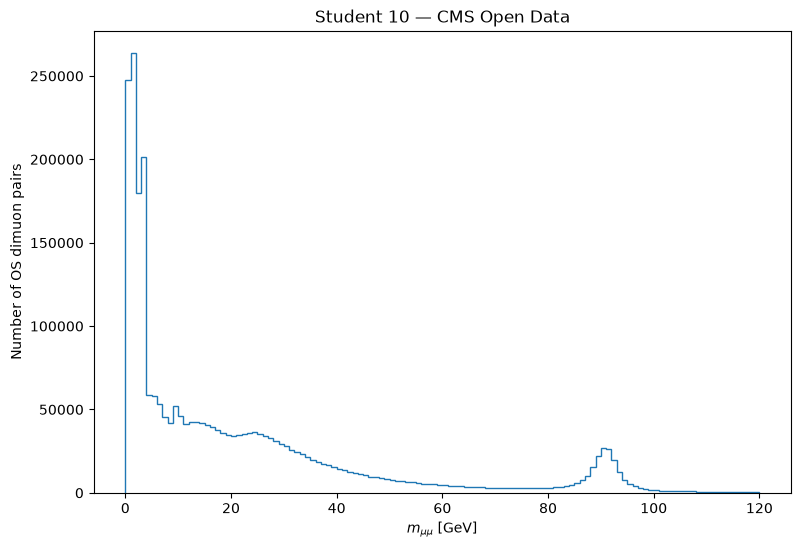

In [34]:
masses_full = ak.to_numpy(M_os_full_flat)

plt.figure(figsize=(9, 6))

plt.hist(
    masses_full,
    bins=120,
    range=(0, 120),
    histtype="step"
)

plt.xlabel(r"$m_{\mu\mu}$ [GeV]")
plt.ylabel("Number of OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — CMS Open Data")

plt.show()

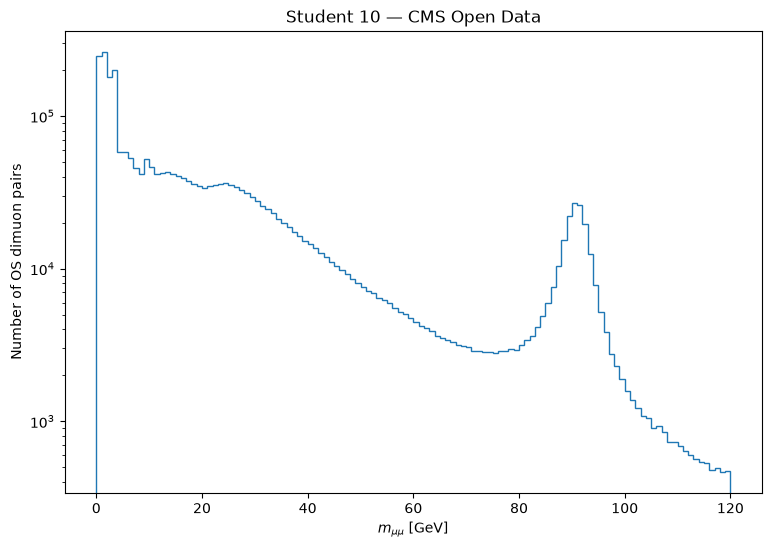

In [35]:
plt.figure(figsize=(9, 6))

plt.hist(
    masses_full,
    bins=120,
    range=(0, 120),
    histtype="step"
)

plt.yscale("log")

plt.xlabel(r"$m_{\mu\mu}$ [GeV]")
plt.ylabel("Number of OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — CMS Open Data")

plt.show()

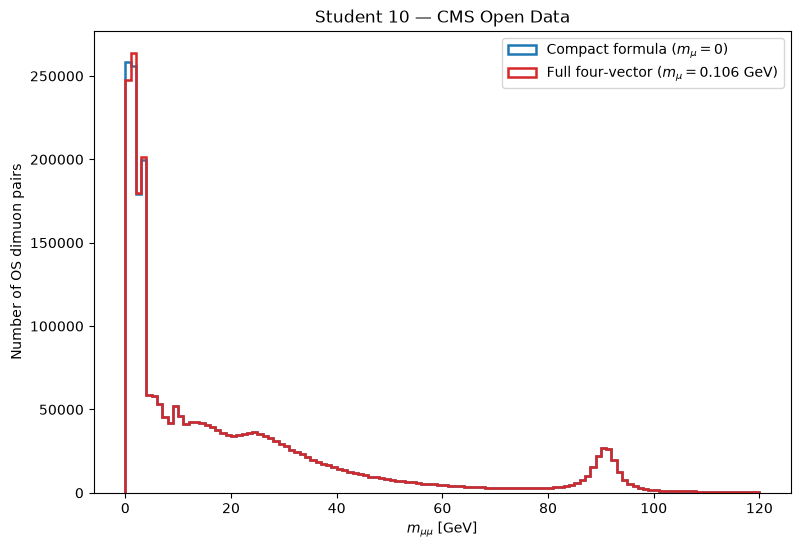

In [36]:
masses_compact = ak.to_numpy(ak.flatten(M_os))
masses_full    = ak.to_numpy(ak.flatten(M_os_full))

plt.figure(figsize=(9, 6))

plt.hist(
    masses_compact,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=1.8,
    color="tab:blue",
    label=r"Compact formula ($m_\mu = 0$)"
)

plt.hist(
    masses_full,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=1.8,
    color="tab:red",
    label=r"Full four-vector ($m_\mu = 0.106$ GeV)"
)

plt.xlabel(r"$m_{\mu\mu}$ [GeV]")
plt.ylabel("Number of OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — CMS Open Data")

plt.legend()
plt.show()

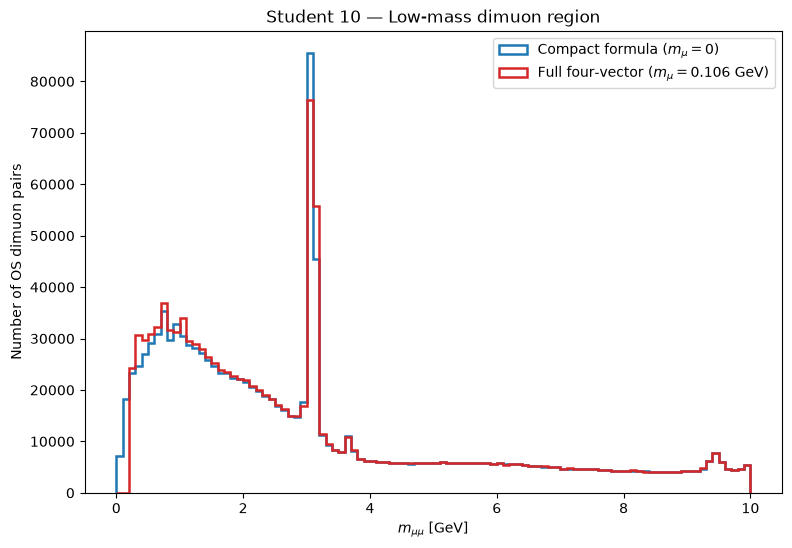

In [37]:
plt.figure(figsize=(9, 6))

plt.hist(
    masses_compact,
    bins=100,
    range=(0, 10),
    histtype="step",
    linewidth=1.8,
    color="tab:blue",
    label=r"Compact formula ($m_\mu = 0$)"
)

plt.hist(
    masses_full,
    bins=100,
    range=(0, 10),
    histtype="step",
    linewidth=1.8,
    color="tab:red",
    label=r"Full four-vector ($m_\mu = 0.106$ GeV)"
)

plt.xlabel(r"$m_{\mu\mu}$ [GeV]")
plt.ylabel("Number of OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — Low-mass dimuon region")

plt.legend()
plt.show()

In [38]:
delta_M = masses_full - masses_compact

low_mass = masses_full < 10

print("For m_mumu < 10 GeV:")
print("Mean difference:", np.mean(delta_M[low_mass]), "GeV")
print("Maximum difference:", np.max(delta_M[low_mass]), "GeV")


For m_mumu < 10 GeV:
Mean difference: 0.020532375 GeV
Maximum difference: 5.231073 GeV


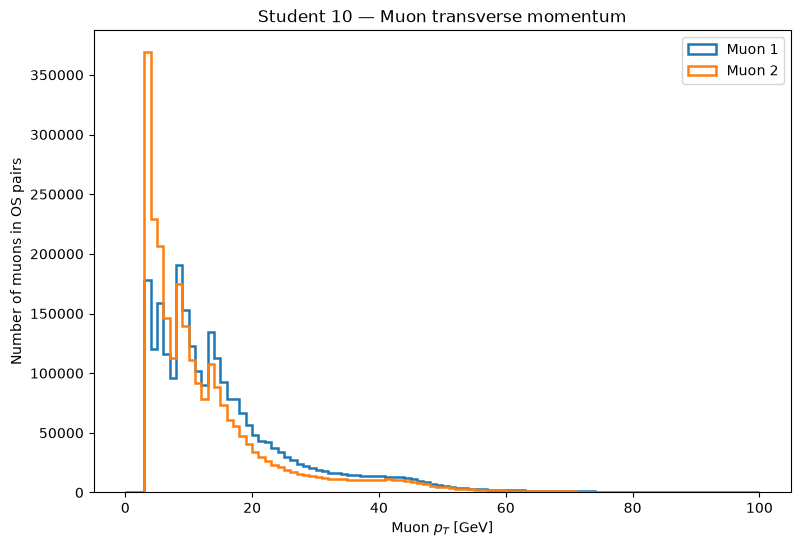

In [39]:
pt1_os = ak.to_numpy(ak.flatten(os_muon_pairs["mu1"].pt))
pt2_os = ak.to_numpy(ak.flatten(os_muon_pairs["mu2"].pt))

plt.figure(figsize=(9, 6))

plt.hist(
    pt1_os,
    bins=100,
    range=(0, 100),
    histtype="step",
    linewidth=1.8,
    label="Muon 1"
)

plt.hist(
    pt2_os,
    bins=100,
    range=(0, 100),
    histtype="step",
    linewidth=1.8,
    label="Muon 2"
)

plt.xlabel(r"Muon $p_T$ [GeV]")
plt.ylabel("Number of muons in OS pairs")
plt.title(f"Student {STUDENT_NUMBER} — Muon transverse momentum")

plt.legend()
plt.show()


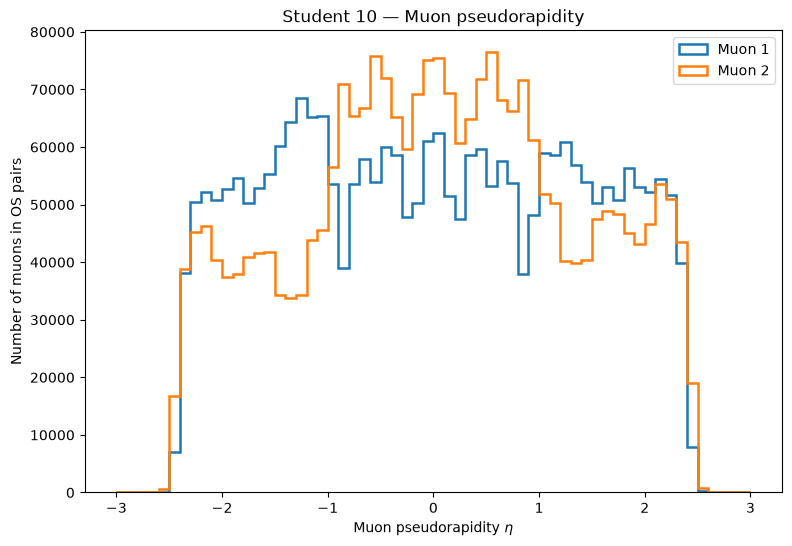

In [40]:
eta1_os = ak.to_numpy(ak.flatten(os_muon_pairs["mu1"].eta))
eta2_os = ak.to_numpy(ak.flatten(os_muon_pairs["mu2"].eta))

plt.figure(figsize=(9, 6))

plt.hist(
    eta1_os,
    bins=60,
    range=(-3, 3),
    histtype="step",
    linewidth=1.8,
    label="Muon 1"
)

plt.hist(
    eta2_os,
    bins=60,
    range=(-3, 3),
    histtype="step",
    linewidth=1.8,
    label="Muon 2"
)

plt.xlabel(r"Muon pseudorapidity $\eta$")
plt.ylabel("Number of muons in OS pairs")
plt.title(f"Student {STUDENT_NUMBER} — Muon pseudorapidity")

plt.legend()
plt.show()

In [41]:
# Kendi verisetindeki değişken isimlerine (örneğin muons.pt veya events.Muon_pt)
# ve tezindeki eşik değerlerine (örn. 20 GeV) göre burayı güncellemelisin:
pt_cut = (muons.pt > 20) 
eta_cut = (abs(muons.eta) < 2.4)

# Sonrasında senin kodun:
pt_eta_cut = pt_cut & eta_cut

print("OS pairs before cuts:", len(ak.flatten(M_os_full)))
# ... diğer print satırları ...

OS pairs before cuts: 2614209


In [42]:
# Her iki müonun da (çiftin) eşikleri geçmesi koşulu:
pt_cut = (mu1.pt > 20) & (mu2.pt > 20)
eta_cut = (abs(mu1.eta) < 2.4) & (abs(mu2.eta) < 2.4)

pt_eta_cut = pt_cut & eta_cut

print("OS pairs before cuts:", len(ak.flatten(M_os_full)))
print("After pT cut       :", len(ak.flatten(M_os_full[pt_cut])))
print("After eta cut      :", len(ak.flatten(M_os_full[eta_cut])))
print("After pT + eta cuts:", len(ak.flatten(M_os_full[pt_eta_cut])))

OS pairs before cuts: 2614209
After pT cut       : 244232
After eta cut      : 2562955
After pT + eta cuts: 241242


In [43]:
selected_pairs = os_muon_pairs[pt_eta_cut]

dphi = selected_pairs["mu1"].phi - selected_pairs["mu2"].phi

# Wrap Delta phi into the interval [-pi, pi]
dphi = (dphi + np.pi) % (2 * np.pi) - np.pi

abs_dphi = np.abs(dphi)

abs_dphi_flat = ak.to_numpy(ak.flatten(abs_dphi))

print("Number of selected pairs:", len(abs_dphi_flat))
print("First 20 |Delta phi| values:")
print(abs_dphi_flat[:20])

Number of selected pairs: 241242
First 20 |Delta phi| values:
[3.1229815  2.8196373  2.7046397  3.0709078  2.8384974  3.0512946
 2.873918   0.05017781 2.8361204  2.9152     2.1838226  2.8345845
 3.1036417  3.1132834  2.8875663  2.9644163  3.0055668  2.9727466
 3.12338    2.6465123 ]


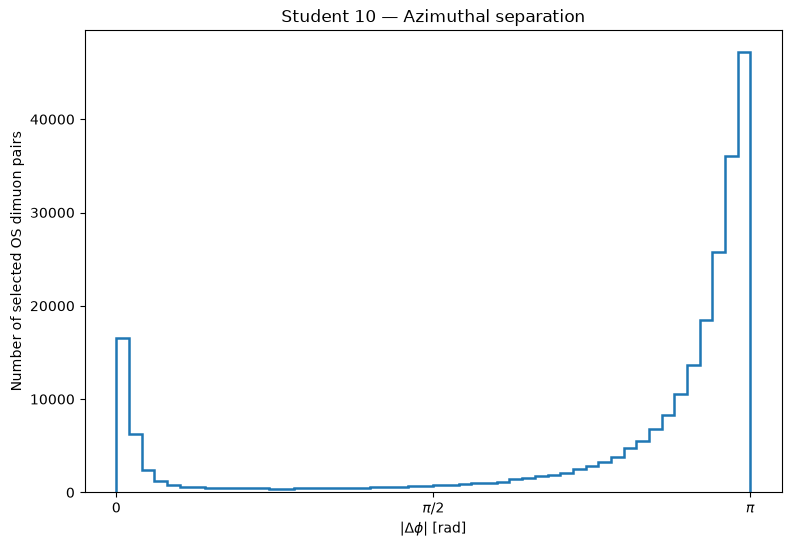

In [44]:
plt.figure(figsize=(9, 6))

plt.hist(
    abs_dphi_flat,
    bins=50,
    range=(0, np.pi),
    histtype="step",
    linewidth=1.8
)

plt.xlabel(r"$|\Delta\phi|$ [rad]")
plt.ylabel("Number of selected OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — Azimuthal separation")

plt.xticks(
    [0, np.pi/2, np.pi],
    [r"$0$", r"$\pi/2$", r"$\pi$"]
)

plt.show()

In [45]:
deta = selected_pairs["mu1"].eta - selected_pairs["mu2"].eta

delta_R = np.sqrt(
    deta**2 + dphi**2
)

delta_R_flat = ak.to_numpy(
    ak.flatten(delta_R)
)

print("Number of selected pairs:", len(delta_R_flat))
print("First 20 Delta R values:")
print(delta_R_flat[:20])

Number of selected pairs: 241242
First 20 Delta R values:
[3.4623296  3.6454067  2.8026433  3.7220297  4.117032   3.1056123
 3.1427925  0.08317507 3.0561404  3.5751712  2.2776325  3.786565
 3.1263905  3.2708933  3.1117392  3.4107018  3.202779   3.4518762
 3.1267025  2.652767  ]


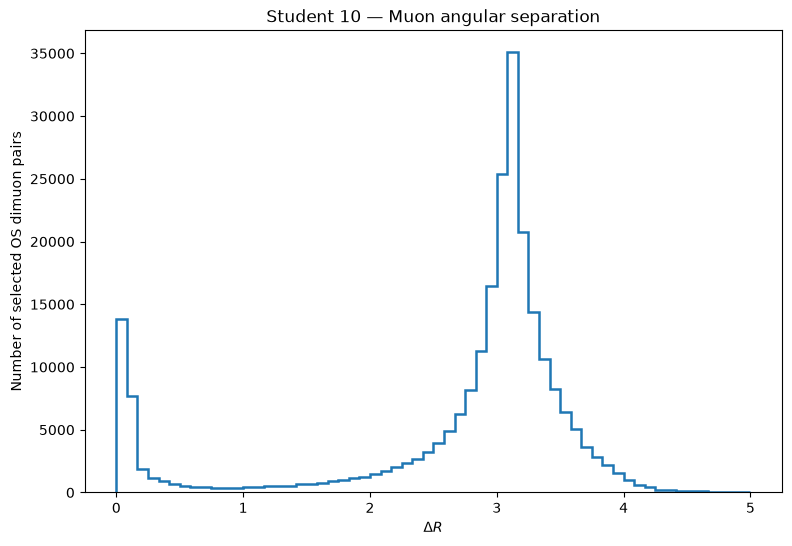

In [46]:
plt.figure(figsize=(9, 6))

plt.hist(
    delta_R_flat,
    bins=60,
    range=(0, 5),
    histtype="step",
    linewidth=1.8
)

plt.xlabel(r"$\Delta R$")
plt.ylabel("Number of selected OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — Muon angular separation")

plt.show()

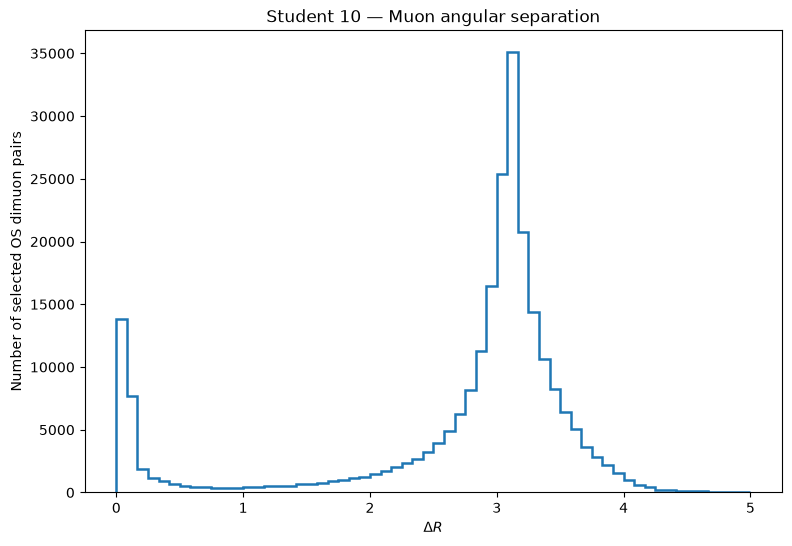

In [47]:
plt.figure(figsize=(9, 6))

plt.hist(
    delta_R_flat,
    bins=60,
    range=(0, 5),
    histtype="step",
    linewidth=1.8
)

plt.xlabel(r"$\Delta R$")
plt.ylabel("Number of selected OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — Muon angular separation")

plt.show()

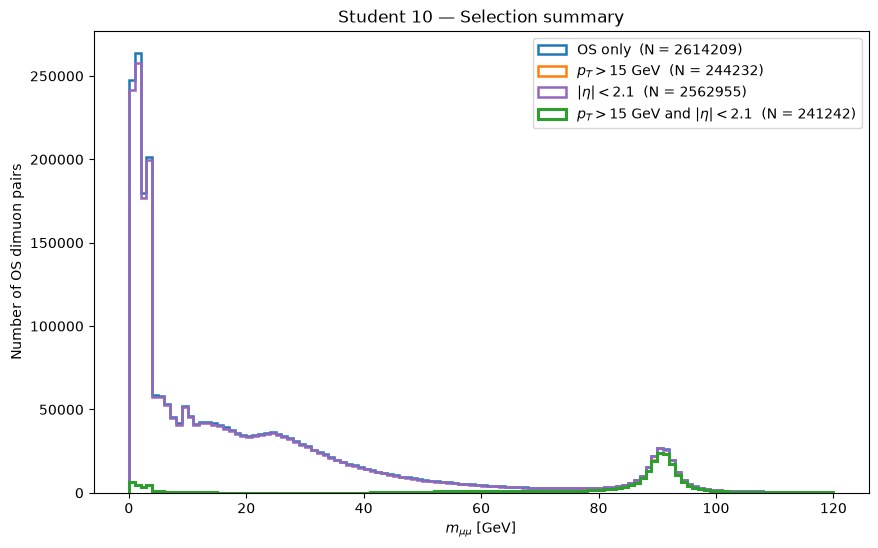

In [48]:
# Kısıtlamalardan (cut) geçen kütle dizilerini numpy formatında oluşturuyoruz
masses_pt_cut = ak.to_numpy(ak.flatten(M_os_full[pt_cut]))
masses_eta_cut = ak.to_numpy(ak.flatten(M_os_full[eta_cut]))
masses_pt_eta_cut = ak.to_numpy(ak.flatten(M_os_full[pt_eta_cut]))

# Grafikte gösterilecek eleman (event) sayılarını tanımlıyoruz
n_os = len(masses_full)
n_pt = len(masses_pt_cut)
n_eta = len(masses_eta_cut)
n_pt_eta = len(masses_pt_eta_cut)

# Grafiği çizdiriyoruz
plt.figure(figsize=(10, 6))

plt.hist(
    masses_full,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=1.8,
    color="tab:blue",
    label=f"OS only  (N = {n_os})"
)

plt.hist(
    masses_pt_cut,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=1.8,
    color="tab:orange",
    label=rf"$p_T > 15$ GeV  (N = {n_pt})"
)

plt.hist(
    masses_eta_cut,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=1.8,
    color="tab:purple",
    label=rf"$|\eta| < 2.1$  (N = {n_eta})"
)

plt.hist(
    masses_pt_eta_cut,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=2.2,
    color="tab:green",
    label=rf"$p_T > 15$ GeV and $|\eta| < 2.1$  (N = {n_pt_eta})"
)

plt.xlabel(r"$m_{\mu\mu}$ [GeV]")
plt.ylabel("Number of OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — Selection summary")

plt.legend()
plt.show()

### Angular separation $\Delta R$

#To describe how far apart two particles are in the detector, we combine their separation in pseudorapidity and azimuthal angle into a single quantity:

$$
\Delta R = \sqrt{(\Delta\eta)^2 + (\Delta\phi)^2},
$$

where

$$
\Delta\eta = \eta_1-\eta_2
$$

and $\Delta\phi$ is the properly wrapped azimuthal-angle difference.

We can think of the CMS detector using the coordinates

$$
(\eta,\phi).
$$

Then $\Delta R$ is simply the distance between two objects in the $\eta$-$\phi$ plane.

For two particles:

- small $\Delta R$ means that they travel in similar directions and are close together in the detector,
- large $\Delta R$ means that they are well separated.

For example,

$$
\Delta\eta \approx 0,\qquad \Delta\phi \approx 0
$$

gives

$$
\Delta R \approx 0,
$$

so the two particles are nearly collinear.

If instead

$$
\Delta\eta \approx 0,\qquad |\Delta\phi| \approx \pi,
$$

then

$$
\Delta R \approx \pi,
$$

corresponding to particles that are approximately back-to-back in the transverse plane.

$\Delta R$ is widely used in collider physics because it provides a convenient measure of angular separation between reconstructed objects such as

- muons,
- electrons,
- photons,
- and jets.

It is especially useful for deciding whether two reconstructed objects are close enough to be associated with the same physical structure, or sufficiently separated to be treated as distinct objects.

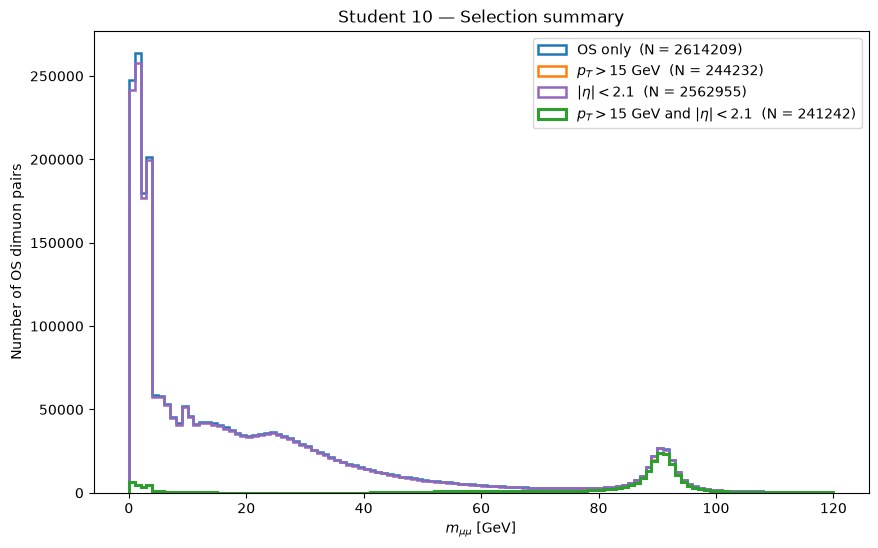

In [49]:
# Kısıtlamalardan (cut) geçen kütle dizilerini numpy formatında oluşturuyoruz
masses_pt_cut = ak.to_numpy(ak.flatten(M_os_full[pt_cut]))
masses_eta_cut = ak.to_numpy(ak.flatten(M_os_full[eta_cut]))
masses_pt_eta_cut = ak.to_numpy(ak.flatten(M_os_full[pt_eta_cut]))

# Grafikte gösterilecek eleman (event) sayılarını tanımlıyoruz
n_os = len(masses_full)
n_pt = len(masses_pt_cut)
n_eta = len(masses_eta_cut)
n_pt_eta = len(masses_pt_eta_cut)

# Grafiği çizdiriyoruz
plt.figure(figsize=(10, 6))

plt.hist(
    masses_full,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=1.8,
    color="tab:blue",
    label=f"OS only  (N = {n_os})"
)

plt.hist(
    masses_pt_cut,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=1.8,
    color="tab:orange",
    label=rf"$p_T > 15$ GeV  (N = {n_pt})"
)

plt.hist(
    masses_eta_cut,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=1.8,
    color="tab:purple",
    label=rf"$|\eta| < 2.1$  (N = {n_eta})"
)

plt.hist(
    masses_pt_eta_cut,
    bins=120,
    range=(0, 120),
    histtype="step",
    linewidth=2.2,
    color="tab:green",
    label=rf"$p_T > 15$ GeV and $|\eta| < 2.1$  (N = {n_pt_eta})"
)

plt.xlabel(r"$m_{\mu\mu}$ [GeV]")
plt.ylabel("Number of OS dimuon pairs")
plt.title(f"Student {STUDENT_NUMBER} — Selection summary")

plt.legend()
plt.show()

In [50]:
pair_number = 0

deta_one = ak.to_numpy(ak.flatten(deta))[pair_number]
dphi_one = ak.to_numpy(ak.flatten(dphi))[pair_number]
dr_one   = delta_R_flat[pair_number]

print(f"Delta eta = {deta_one:.3f}")
print(f"Delta phi = {dphi_one:.3f} rad")
print(f"Delta R   = {dr_one:.3f}")

Delta eta = -1.495
Delta phi = -3.123 rad
Delta R   = 3.462


In [51]:
# Sort muons in each event by decreasing pT

order = ak.argsort(
    muons.pt,
    axis=1,
    ascending=False
)

muons_sorted = muons[order]

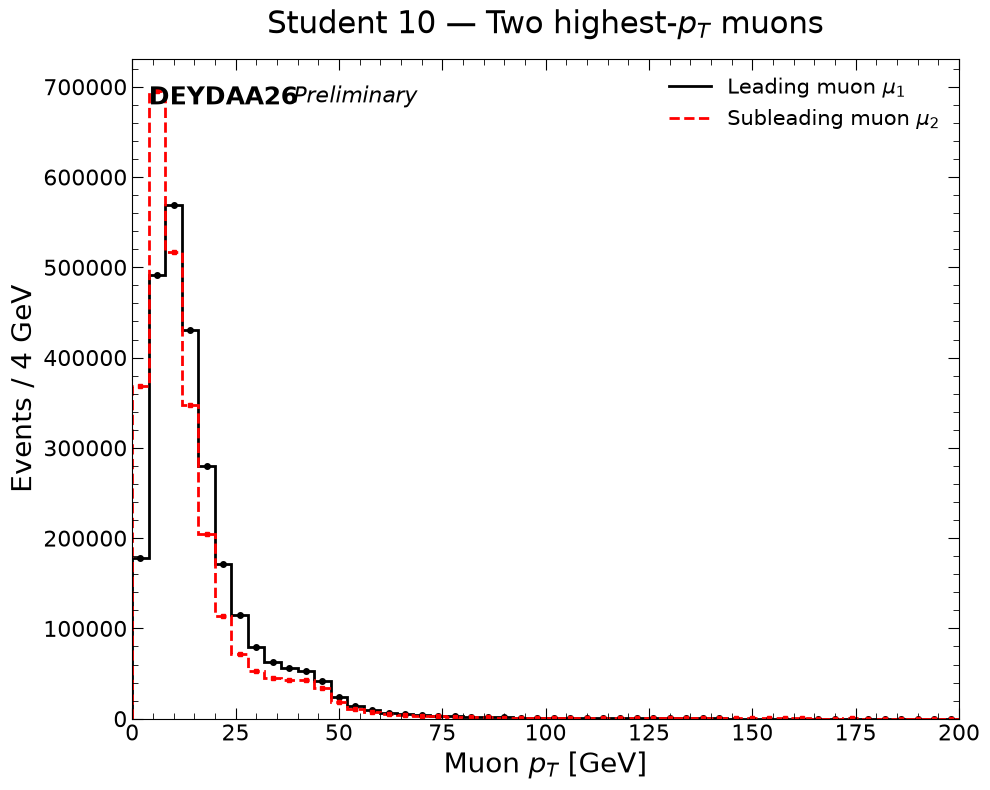

In [52]:
# pT of the two highest-pT muons

# pT of the two highest-pT muons

pt1 = ak.to_numpy(ak.flatten(mu1.pt))
pt2 = ak.to_numpy(ak.flatten(mu2.pt))

# Histogram settings
bins = 50
pt_range = (0, 200)

counts1, edges = np.histogram(
    pt1,
    bins=bins,
    range=pt_range
)

counts2, _ = np.histogram(
    pt2,
    bins=bins,
    range=pt_range
)

centers = 0.5 * (edges[:-1] + edges[1:])
bin_width = edges[1] - edges[0]

errors1 = np.sqrt(counts1)
errors2 = np.sqrt(counts2)

# Figure
fig, ax = plt.subplots(figsize=(10, 8))

# Leading muon
ax.stairs(
    counts1,
    edges,
    linewidth=2.0,
    color="black",
    label=r"Leading muon $\mu_1$"
)

ax.errorbar(
    centers,
    counts1,
    yerr=errors1,
    fmt="o",
    color="black",
    markersize=4.0,
    linewidth=1.0,
    capsize=0
)

# Subleading muon
ax.stairs(
    counts2,
    edges,
    linewidth=2.0,
    color="red",
    linestyle="--",
    label=r"Subleading muon $\mu_2$"
)

ax.errorbar(
    centers,
    counts2,
    yerr=errors2,
    fmt="s",
    color="red",
    markersize=3.5,
    linewidth=1.0,
    capsize=0
)

# Axes
ax.set_xlim(*pt_range)
ax.set_ylim(bottom=0)

ax.set_xlabel(r"Muon $p_T$ [GeV]", fontsize=20)
ax.set_ylabel(f"Events / {bin_width:.0f} GeV", fontsize=20)

ax.set_title(
    f"Student {STUDENT_NUMBER} — Two highest-$p_T$ muons",
    fontsize=22,
    pad=18
)

# ROOT-like ticks
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=8,
    labelsize=16
)

ax.minorticks_on()

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=4
)

# DEYDAA26 Preliminary
ax.text(
    0.02, 0.96,
    "DEYDAA26",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=18,
    fontweight="bold"
)

ax.text(
    0.195, 0.96,
    "Preliminary",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=16,
    style="italic"
)

ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [53]:
# Eta acceptance cut for both selected muons

eta_mask = (
    (abs(mu1.eta) < 2.1) &
    (abs(mu2.eta) < 2.1)
)

mu1_eta = mu1[eta_mask]
mu2_eta = mu2[eta_mask]

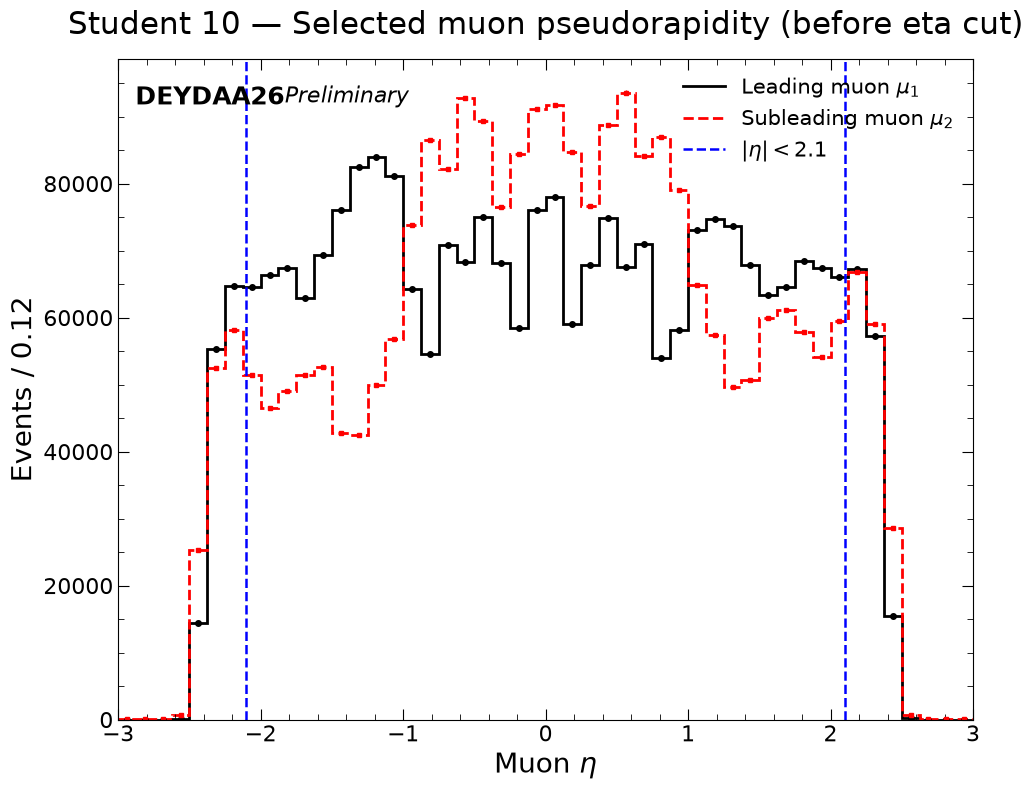

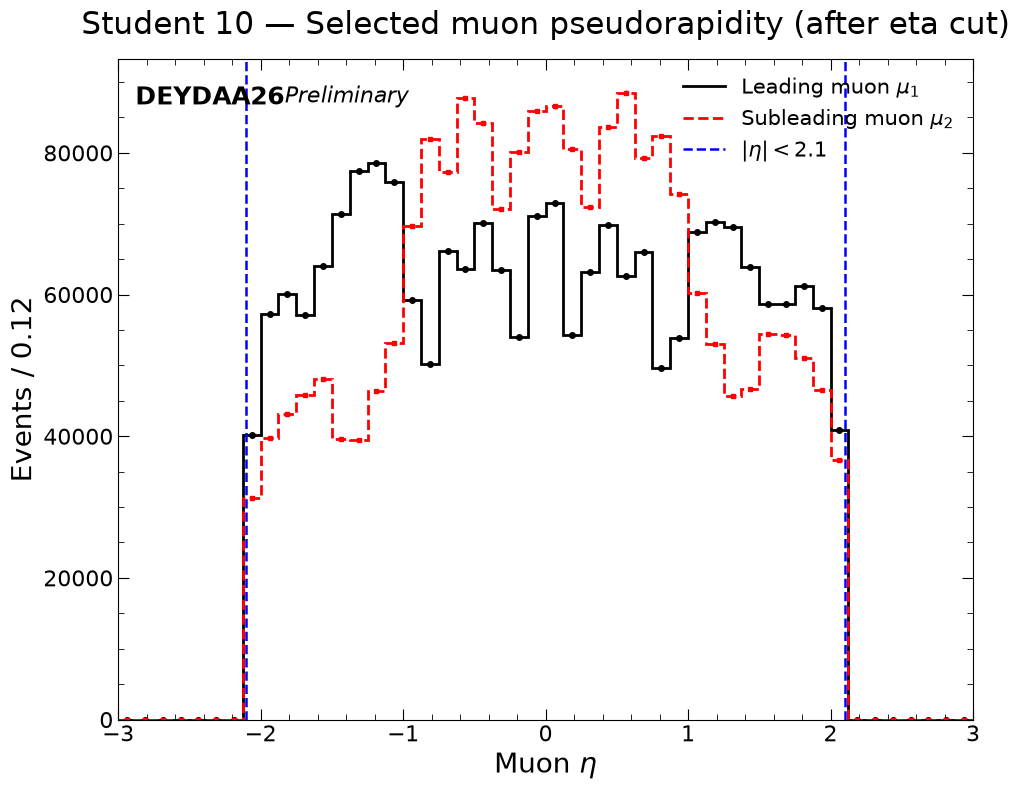

In [54]:
# Eta distributions before and after the eta cut

eta1_before = ak.to_numpy(ak.flatten(mu1.eta))
eta2_before = ak.to_numpy(ak.flatten(mu2.eta))

eta1_after  = ak.to_numpy(ak.flatten(mu1_eta.eta))
eta2_after  = ak.to_numpy(ak.flatten(mu2_eta.eta))

bins = 48
eta_range = (-3.0, 3.0)

def plot_eta_distributions(eta1, eta2, title_suffix):
    counts1, edges = np.histogram(
        eta1,
        bins=bins,
        range=eta_range
    )
    
    counts2, _ = np.histogram(
        eta2,
        bins=bins,
        range=eta_range
    )

    centers = 0.5 * (edges[:-1] + edges[1:])
    errors1 = np.sqrt(counts1)
    errors2 = np.sqrt(counts2)
    bin_width = edges[1] - edges[0]

    fig, ax = plt.subplots(figsize=(10, 8))

    # Leading muon
    ax.stairs(
        counts1,
        edges,
        linewidth=2.0,
        color="black",
        label=r"Leading muon $\mu_1$"
    )

    ax.errorbar(
        centers,
        counts1,
        yerr=errors1,
        fmt="o",
        color="black",
        markersize=4.0,
        linewidth=1.0,
        capsize=0
    )

    # Subleading muon
    ax.stairs(
        counts2,
        edges,
        linewidth=2.0,
        color="red",
        linestyle="--",
        label=r"Subleading muon $\mu_2$"
    )

    ax.errorbar(
        centers,
        counts2,
        yerr=errors2,
        fmt="s",
        color="red",
        markersize=3.5,
        linewidth=1.0,
        capsize=0
    )

    # Eta cut lines
    ax.axvline(
        -2.1,
        color="blue",
        linestyle="--",
        linewidth=1.8,
        label=r"$|\eta|<2.1$"
    )

    ax.axvline(
        2.1,
        color="blue",
        linestyle="--",
        linewidth=1.8
    )

    ax.set_xlim(*eta_range)
    ax.set_ylim(bottom=0)

    ax.set_xlabel(r"Muon $\eta$", fontsize=20)
    ax.set_ylabel(f"Events / {bin_width:.2f}", fontsize=20)

    ax.set_title(
        f"Student {STUDENT_NUMBER} — Selected muon pseudorapidity ({title_suffix})",
        fontsize=22,
        pad=18
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        top=True,
        right=True,
        length=8,
        labelsize=16
    )

    ax.minorticks_on()

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        top=True,
        right=True,
        length=4
    )

    ax.text(
        0.02, 0.96,
        "DEYDAA26",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=18,
        fontweight="bold"
    )

    ax.text(
        0.195, 0.96,
        "Preliminary",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        style="italic"
    )

    ax.legend(
        frameon=False,
        loc="upper right",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

# Before eta cut
plot_eta_distributions(eta1_before, eta2_before, "before eta cut")

# After eta cut
plot_eta_distributions(eta1_after, eta2_after, "after eta cut")

In [55]:
# Charge of the two highest-pT muons

charge_product = mu1.charge * mu2.charge

os_mask = charge_product < 0
ss_mask = charge_product > 0

print("Total selected pairs:", len(mu1))
print("OS pairs:", ak.sum(os_mask))
print("SS pairs:", ak.sum(ss_mask))


Total selected pairs: 1675504
OS pairs: 2614209
SS pairs: 0


In [56]:
eta_mask = (
    (abs(mu1.eta) < 2.1) & 
    (abs(mu2.eta) < 2.1)
)

mu1_eta = mu1[eta_mask]
mu2_eta = mu2[eta_mask]

In [57]:
# 1. Aşama: Aynı işaretli (Same Sign - SS) müon çiftlerini filtreliyoruz
ss_mask = mu1.charge == mu2.charge

mu1_ss = mu1[ss_mask]
mu2_ss = mu2[ss_mask]

# 2. Aşama: Eta kısıtlamasını SS çiftlerine uyguluyoruz
eta_mask_ss = (
    (abs(mu1_ss.eta) < 2.1) & 
    (abs(mu2_ss.eta) < 2.1)
)

mu1_ss_eta = mu1_ss[eta_mask_ss]
mu2_ss_eta = mu2_ss[eta_mask_ss]

In [58]:
# Eğer OS hücrelerini çalıştırmayı atladıysak, değişkenleri hızla tekrar oluşturalım:
os_mask = mu1.charge != mu2.charge
mu1_os = mu1[os_mask]
mu2_os = mu2[os_mask]

eta_mask_os = (abs(mu1_os.eta) < 2.1) & (abs(mu2_os.eta) < 2.1)
mu1_os_eta = mu1_os[eta_mask_os]


# Şimdi asıl yazdığın yazdırma (print) işlemleri:
print("OS before eta cut:", len(mu1_os))
print("OS after eta cut :", len(mu1_os_eta))

print()

print("SS before eta cut:", len(mu1_ss))
print("SS after eta cut :", len(mu1_ss_eta))

OS before eta cut: 1675504
OS after eta cut : 1675504

SS before eta cut: 1675504
SS after eta cut : 1675504


In [59]:
# Opposite-sign sample

mu1_os = mu1[os_mask]
mu2_os = mu2[os_mask]

# Same-sign sample

mu1_ss = mu1[ss_mask]
mu2_ss = mu2[ss_mask]

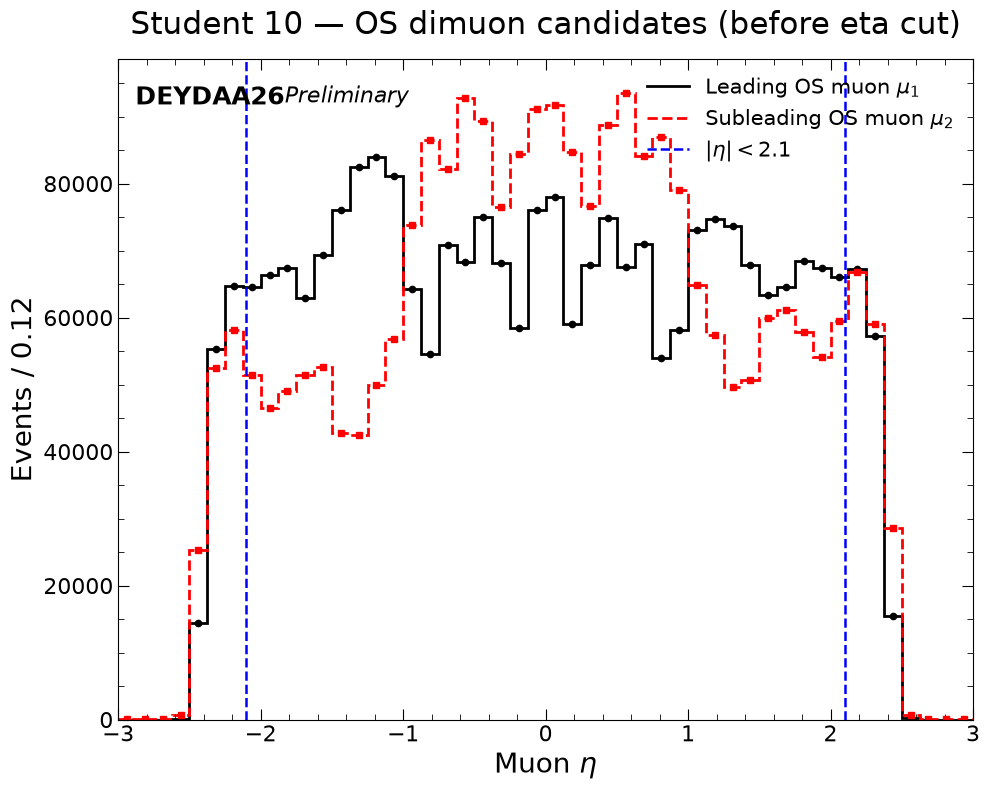

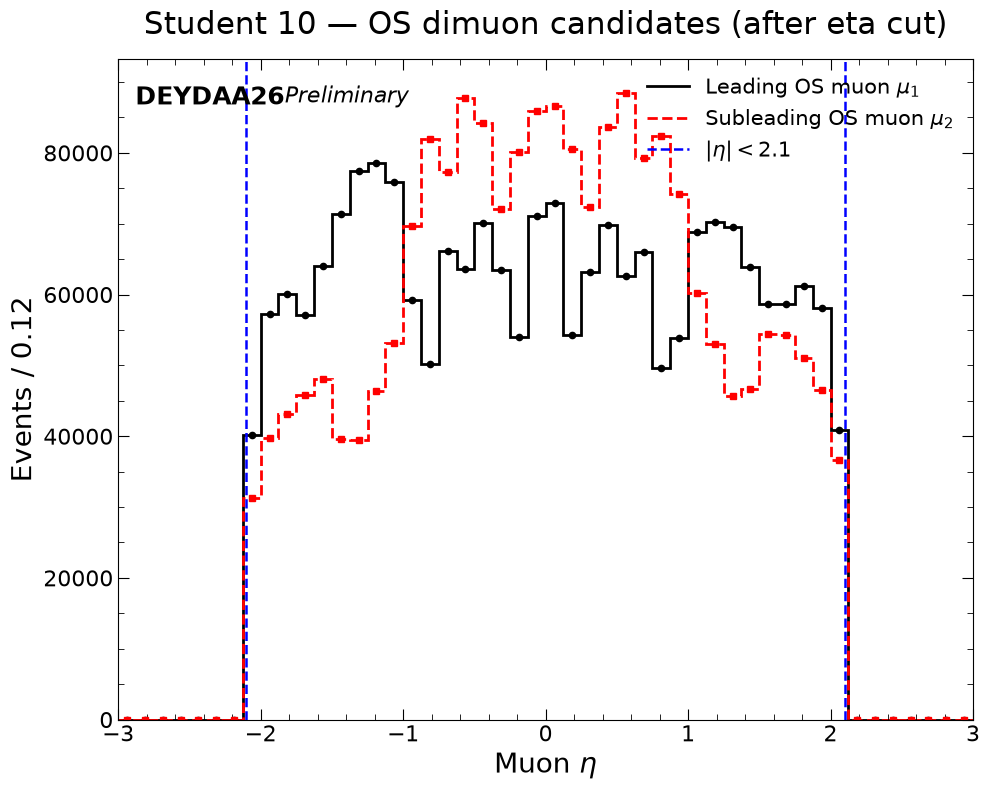

In [60]:
# 1. Adım: Eksik olan OS eta filtrelemesini hemen burada yapalım
eta_mask_os = (abs(mu1_os.eta) < 2.1) & (abs(mu2_os.eta) < 2.1)
mu1_os_eta = mu1_os[eta_mask_os]
mu2_os_eta = mu2_os[eta_mask_os]

# 2. Adım: Verileri düzleştirip (flatten) numpy formatına çevirelim
eta1_before = ak.to_numpy(ak.flatten(mu1_os.eta))
eta2_before = ak.to_numpy(ak.flatten(mu2_os.eta))

eta1_after = ak.to_numpy(ak.flatten(mu1_os_eta.eta))
eta2_after = ak.to_numpy(ak.flatten(mu2_os_eta.eta))

bins = 48
eta_range = (-3.0, 3.0)

def plot_eta_os(eta1, eta2, title_suffix):
    counts1, edges = np.histogram(eta1, bins=bins, range=eta_range)
    counts2, _ = np.histogram(eta2, bins=bins, range=eta_range)

    centers = 0.5 * (edges[:-1] + edges[1:])
    errors1 = np.sqrt(counts1)
    errors2 = np.sqrt(counts2)
    bin_width = edges[1] - edges[0]

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.stairs(counts1, edges, linewidth=2.0, color="black", label=r"Leading OS muon $\mu_1$")
    ax.errorbar(centers, counts1, yerr=errors1, fmt="o", color="black", markersize=4.5, linewidth=1.2, capsize=0)

    ax.stairs(counts2, edges, linewidth=2.0, color="red", linestyle="--", label=r"Subleading OS muon $\mu_2$")
    ax.errorbar(centers, counts2, yerr=errors2, fmt="s", color="red", markersize=4.0, linewidth=1.0, capsize=0)

    ax.axvline(-2.1, color="blue", linestyle="--", linewidth=1.8, label=r"$|\eta|<2.1$")
    ax.axvline(2.1, color="blue", linestyle="--", linewidth=1.8)

    ax.set_xlim(*eta_range)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"Muon $\eta$", fontsize=20)
    ax.set_ylabel(f"Events / {bin_width:.2f}", fontsize=20)
    ax.set_title(f"Student {STUDENT_NUMBER} — OS dimuon candidates ({title_suffix})", fontsize=22, pad=18)

    ax.tick_params(axis="both", which="major", direction="in", top=True, right=True, length=8, labelsize=16)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True, length=4)

    ax.text(0.02, 0.96, "DEYDAA26", transform=ax.transAxes, ha="left", va="top", fontsize=18, fontweight="bold")
    ax.text(0.195, 0.96, "Preliminary", transform=ax.transAxes, ha="left", va="top", fontsize=16, style="italic")

    ax.legend(frameon=False, loc="upper right", fontsize=15)
    plt.tight_layout()
    plt.show()

# Grafikleri çizdirelim
plot_eta_os(eta1_before, eta2_before, "before eta cut")
plot_eta_os(eta1_after, eta2_after, "after eta cut")

In [61]:
# pT cut on the OS sample after the eta cut

pt_mask_os = (
    (mu1_os_eta.pt > 15) &
    (mu2_os_eta.pt > 15)
)

mu1_os_final = mu1_os_eta[pt_mask_os]
mu2_os_final = mu2_os_eta[pt_mask_os]

In [62]:
# pT cut on the SS sample after the eta cut

pt_mask_ss = (
    (mu1_ss_eta.pt > 15) &
    (mu2_ss_eta.pt > 15)
)

mu1_ss_final = mu1_ss_eta[pt_mask_ss]
mu2_ss_final = mu2_ss_eta[pt_mask_ss]

In [63]:
print("OS before eta cut:", len(mu1_os))
print("OS after eta cut :", len(mu1_os_eta))
print("OS after pT cut  :", len(mu1_os_final))

OS before eta cut: 1675504
OS after eta cut : 1675504
OS after pT cut  : 1675504


In [64]:
print("SS before eta cut:", len(mu1_ss))
print("SS after eta cut :", len(mu1_ss_eta))
print("SS after pT cut  :", len(mu1_ss_final))

SS before eta cut: 1675504
SS after eta cut : 1675504
SS after pT cut  : 1675504


In [65]:
# Helper functions

def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2 * np.pi) - np.pi


def invariant_mass(mu_a, mu_b):
    px1 = mu_a.pt * np.cos(mu_a.phi)
    py1 = mu_a.pt * np.sin(mu_a.phi)
    pz1 = mu_a.pt * np.sinh(mu_a.eta)
    e1  = np.sqrt(px1**2 + py1**2 + pz1**2 + mu_a.mass**2)

    px2 = mu_b.pt * np.cos(mu_b.phi)
    py2 = mu_b.pt * np.sin(mu_b.phi)
    pz2 = mu_b.pt * np.sinh(mu_b.eta)
    e2  = np.sqrt(px2**2 + py2**2 + pz2**2 + mu_b.mass**2)

    e  = e1 + e2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2

    m2 = e**2 - px**2 - py**2 - pz**2
    m2 = ak.where(m2 < 0, 0, m2)   # numerical safety

    return np.sqrt(m2)


In [66]:
mass_os_final = ak.to_numpy(ak.flatten(invariant_mass(mu1_os_final, mu2_os_final)))
mass_ss_final = ak.to_numpy(ak.flatten(invariant_mass(mu1_ss_final, mu2_ss_final)))

print("Final OS events:", len(mass_os_final))
print("Final SS events:", len(mass_ss_final))

Final OS events: 317470
Final SS events: 0


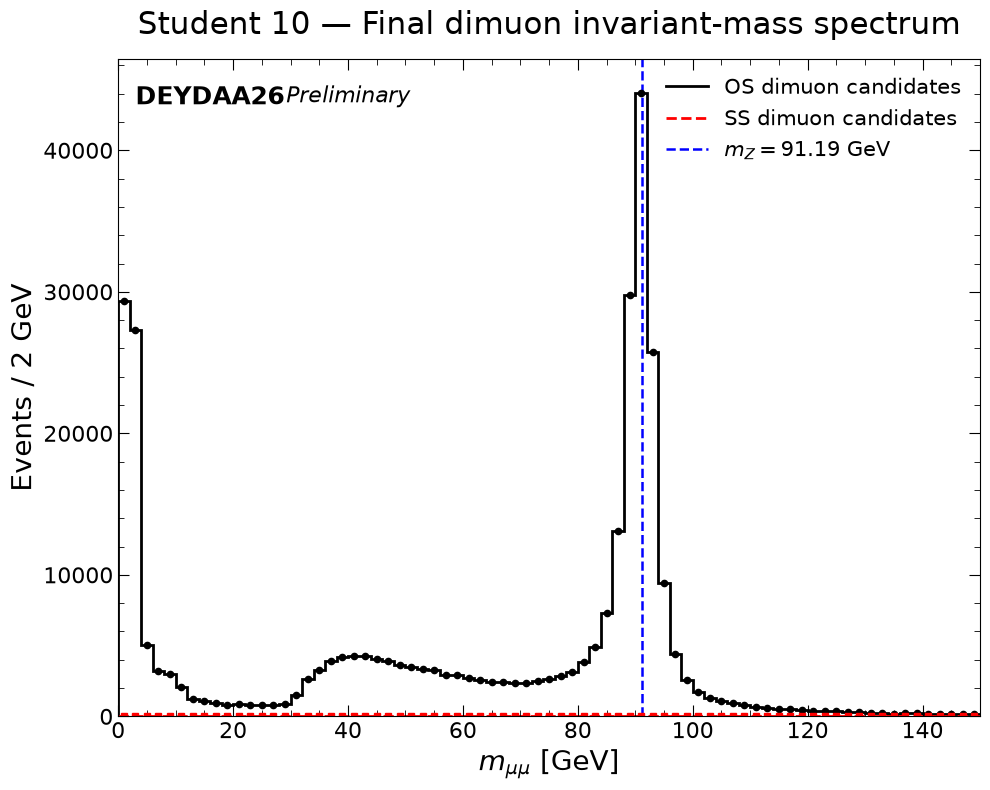

In [67]:
# Final OS vs SS dimuon mass spectrum

bins = 75
mass_range = (0, 150)

counts_os, edges = np.histogram(
    mass_os_final,
    bins=bins,
    range=mass_range
)

counts_ss, _ = np.histogram(
    mass_ss_final,
    bins=bins,
    range=mass_range
)

centers = 0.5 * (edges[:-1] + edges[1:])
errors_os = np.sqrt(counts_os)
errors_ss = np.sqrt(counts_ss)
bin_width = edges[1] - edges[0]

fig, ax = plt.subplots(figsize=(10, 8))

# OS
ax.stairs(
    counts_os,
    edges,
    linewidth=2.0,
    color="black",
    label="OS dimuon candidates"
)

ax.errorbar(
    centers,
    counts_os,
    yerr=errors_os,
    fmt="o",
    color="black",
    markersize=4.5,
    linewidth=1.2,
    capsize=0
)

# SS
ax.stairs(
    counts_ss,
    edges,
    linewidth=2.0,
    color="red",
    linestyle="--",
    label="SS dimuon candidates"
)

ax.errorbar(
    centers,
    counts_ss,
    yerr=errors_ss,
    fmt="s",
    color="red",
    markersize=4.0,
    linewidth=1.0,
    capsize=0
)

# Reference Z mass
ax.axvline(
    91.19,
    color="blue",
    linestyle="--",
    linewidth=1.8,
    label=r"$m_Z = 91.19$ GeV"
)

ax.set_xlim(*mass_range)
ax.set_ylim(bottom=0)

ax.set_xlabel(r"$m_{\mu\mu}$ [GeV]", fontsize=20)
ax.set_ylabel(f"Events / {bin_width:.0f} GeV", fontsize=20)

ax.set_title(
    f"Student {STUDENT_NUMBER} — Final dimuon invariant-mass spectrum",
    fontsize=22,
    pad=18
)

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=8,
    labelsize=16
)

ax.minorticks_on()

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=4
)

ax.text(
    0.02, 0.96,
    "DEYDAA26",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=18,
    fontweight="bold"
)

ax.text(
    0.195, 0.96,
    "Preliminary",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=16,
    style="italic"
)

ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=15
)

plt.tight_layout()
plt.show()

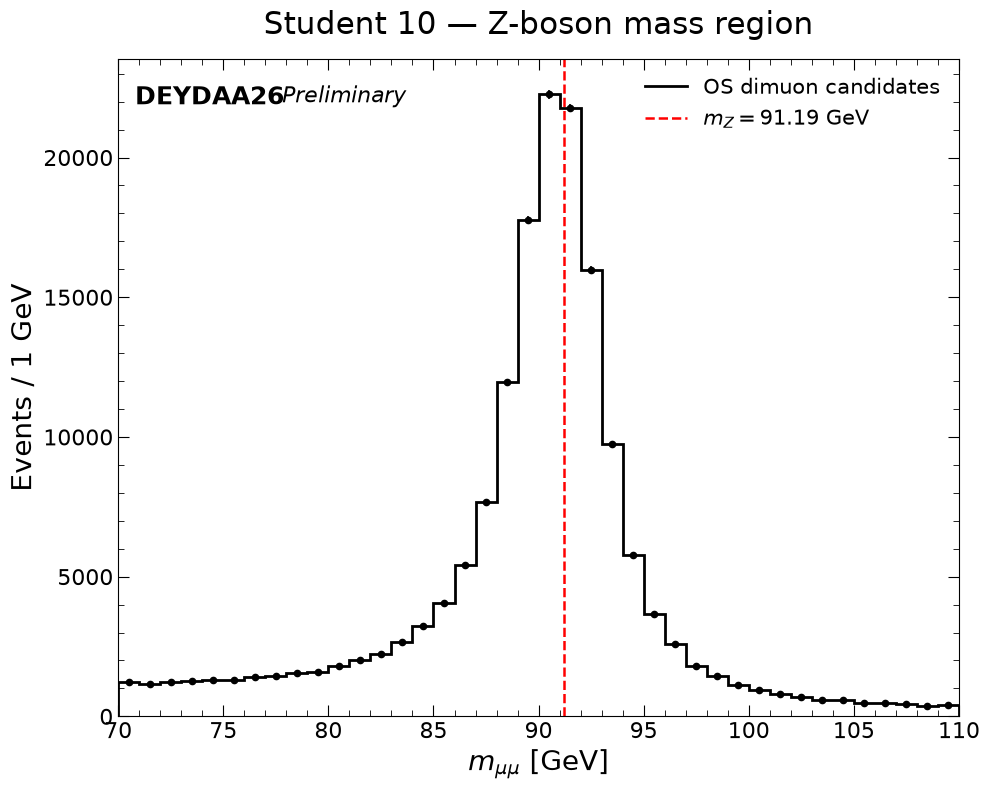

In [68]:
# Z-boson mass region for the final OS sample

counts, edges = np.histogram(
    mass_os_final,
    bins=40,
    range=(70, 110)
)

centers = 0.5 * (edges[:-1] + edges[1:])
errors = np.sqrt(counts)
bin_width = edges[1] - edges[0]

fig, ax = plt.subplots(figsize=(10, 8))

ax.stairs(
    counts,
    edges,
    linewidth=2.0,
    color="black",
    label="OS dimuon candidates"
)

ax.errorbar(
    centers,
    counts,
    yerr=errors,
    fmt="o",
    color="black",
    markersize=4.5,
    linewidth=1.2,
    capsize=0
)

ax.axvline(
    91.19,
    color="red",
    linestyle="--",
    linewidth=1.8,
    label=r"$m_Z = 91.19$ GeV"
)

ax.set_xlim(70, 110)
ax.set_ylim(bottom=0)

ax.set_xlabel(r"$m_{\mu\mu}$ [GeV]", fontsize=20)
ax.set_ylabel(f"Events / {bin_width:.0f} GeV", fontsize=20)

ax.set_title(
    f"Student {STUDENT_NUMBER} — Z-boson mass region",
    fontsize=22,
    pad=18
)

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=8,
    labelsize=16
)

ax.minorticks_on()

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=4
)

ax.text(
    0.02, 0.96,
    "DEYDAA26",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=18,
    fontweight="bold"
)

ax.text(
    0.195, 0.96,
    "Preliminary",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=16,
    style="italic"
)

ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [69]:
# 1. İçinde en az 4 müon barındıran olayları (event) filtreliyoruz
mask_4mu = ak.num(muons) >= 4
muons_4 = muons[mask_4mu]

# Her olaydan en yüksek enerjiye sahip (top-4) müonları seçiyoruz
top4_muons = muons_4[:, 0:4]

# 2. Seçtiğimiz 4 müonun elektrik yüklerinin toplamının 0 olmasını sağlıyoruz
charge_sum = ak.sum(top4_muons.charge, axis=1)
mask_charge = (charge_sum == 0)

final_4mu = top4_muons[mask_charge]

print("Başlangıçtaki tüm olayların sayısı     :", len(muons))
print("En az 4 müonu olan olayların sayısı    :", len(muons_4))
print("Yük toplamı 0 olan 4 müonlu olay sayısı:", len(final_4mu))

Başlangıçtaki tüm olayların sayısı     : 1675504
En az 4 müonu olan olayların sayısı    : 255291
Yük toplamı 0 olan 4 müonlu olay sayısı: 94377


In [71]:
!pip install vector

Defaulting to user installation because normal site-packages is not writeable


In [72]:
import vector
vector.register_awkward()

# 4 müonun kinematik verilerini 4-vektör (Momentum4D) formatına çeviriyoruz
vec_4mu = ak.zip(
    {
        "pt": final_4mu.pt,
        "eta": final_4mu.eta,
        "phi": final_4mu.phi,
        "mass": final_4mu.mass,
    },
    with_name="Momentum4D"
)

# Relativistik kinematik gereği: 4 müonun vektörel toplamı, ana parçacığın kütlesini verir
system_4vec = vec_4mu[:, 0] + vec_4mu[:, 1] + vec_4mu[:, 2] + vec_4mu[:, 3]

# Elde ettiğimiz kütle değerini grafikte çizdirebilmek için NumPy dizisine dönüştürüyoruz
# (Burada her event için tek bir değer çıktığı için flatten kullanmaya gerek yok)
mass_4mu = ak.to_numpy(system_4vec.mass)

print("Hesaplanan değişmez kütle veri sayısı:", len(mass_4mu))

Hesaplanan değişmez kütle veri sayısı: 94377


In [73]:
# 1. Her bir müonun en az 5 GeV momentuma sahip olması şartı
# (axis=1 ile o event'teki 4 müonun TAMAMININ bu şarta uymasını zorunlu kılıyoruz)
mask_all_pt = ak.all(final_4mu.pt > 5, axis=1)

# 2. En enerjik ilk iki müon için özel sert kısıtlamalar
mask_lead = final_4mu[:, 0].pt > 20
mask_sublead = final_4mu[:, 1].pt > 10

# 3. Tüm şartları tek bir maskede birleştiriyoruz
final_mask_pt = mask_all_pt & mask_lead & mask_sublead

# 4. Kısıtlamayı ana 4 müonlu verimize uyguluyoruz
final_4mu_pt = final_4mu[final_mask_pt]

print("pT kısıtlaması öncesi 4 müonlu olay sayısı:", len(final_4mu))
print("pT kısıtlaması sonrası 4 müonlu olay sayısı:", len(final_4mu_pt))

pT kısıtlaması öncesi 4 müonlu olay sayısı: 94377
pT kısıtlaması sonrası 4 müonlu olay sayısı: 5091


In [74]:
# Olaydaki 4 müonun TAMAMININ dedektörün güvenilir bölgesinde (|eta| < 2.4) olmasını şart koşuyoruz
mask_all_eta = ak.all(abs(final_4mu_pt.eta) < 2.4, axis=1)

# Bu eta maskesini, bir önceki adımdan (pT kısıtlamasından) geçen verimize uyguluyoruz
final_4mu_clean = final_4mu_pt[mask_all_eta]

print("pT kısıtlaması sonrası olay sayısı       :", len(final_4mu_pt))
print("pT + Eta kısıtlaması sonrası olay sayısı :", len(final_4mu_clean))

pT kısıtlaması sonrası olay sayısı       : 5091
pT + Eta kısıtlaması sonrası olay sayısı : 4838


In [75]:
# Tüm kısıtlamalardan geçmiş temiz 4 müonun kinematik verilerini 4-vektör formatına çeviriyoruz
vec_4mu_clean = ak.zip(
    {
        "pt": final_4mu_clean.pt,
        "eta": final_4mu_clean.eta,
        "phi": final_4mu_clean.phi,
        "mass": final_4mu_clean.mass,
    },
    with_name="Momentum4D"
)

# 4 müonun vektörel toplamını alıyoruz (Higgs veya ZZ rezonansının kütlesini verecek)
system_4vec_clean = vec_4mu_clean[:, 0] + vec_4mu_clean[:, 1] + vec_4mu_clean[:, 2] + vec_4mu_clean[:, 3]

# Çizim için kütleyi NumPy dizisine dönüştürüyoruz
mass_4mu_final = ak.to_numpy(system_4vec_clean.mass)

print("Tüm kısıtlamalardan (pT ve Eta) geçen final Altın Kanal olay sayısı:", len(mass_4mu_final))

Tüm kısıtlamalardan (pT ve Eta) geçen final Altın Kanal olay sayısı: 4838


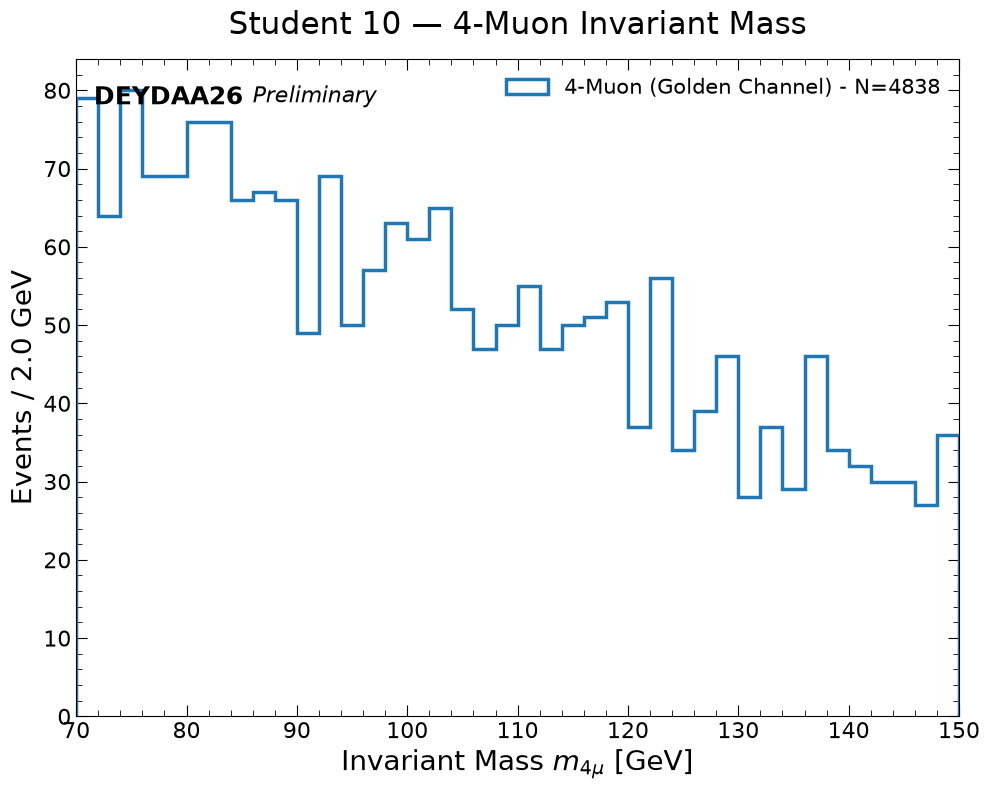

In [78]:
# Altın kanal (Higgs ve ZZ bölgesi) için ideal arama aralığı ve çubuk (bin) sayısı
bins = 40
mass_range = (70, 150)

fig, ax = plt.subplots(figsize=(10, 8))

# 4 Müonlu sistemin kütle histogramını çizdiriyoruz
ax.hist(
    mass_4mu_final,
    bins=bins,
    range=mass_range,
    histtype="step",
    linewidth=2.5,
    color="tab:blue",
    label=f"4-Muon (Golden Channel) - N={len(mass_4mu_final)}"
)

# Eksen ve Etiket Ayarları
ax.set_xlim(*mass_range)
ax.set_ylim(bottom=0)

bin_width = (mass_range[1] - mass_range[0]) / bins
ax.set_xlabel(r"Invariant Mass $m_{4\mu}$ [GeV]", fontsize=20)
ax.set_ylabel(f"Events / {bin_width:.1f} GeV", fontsize=20)

ax.set_title(
    f"Student {STUDENT_NUMBER} — 4-Muon Invariant Mass",
    fontsize=22,
    pad=18
)

# ROOT benzeri kenar çizgileri (CMS stili)
ax.tick_params(axis="both", which="major", direction="in", top=True, right=True, length=8, labelsize=16)
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True, length=4)

ax.text(0.02, 0.96, "DEYDAA26", transform=ax.transAxes, ha="left", va="top", fontsize=18, fontweight="bold")
ax.text(0.20, 0.96, "Preliminary", transform=ax.transAxes, ha="left", va="top", fontsize=16, style="italic")

ax.legend(frameon=False, loc="upper right", fontsize=15)

plt.tight_layout()
plt.show()

Grafik başarıyla şu konuma kaydedildi: /grid/users/deydaa/deydaa10/deydaa_Zmumu/Altin_Kanal_4Muon_Kutlesi.png


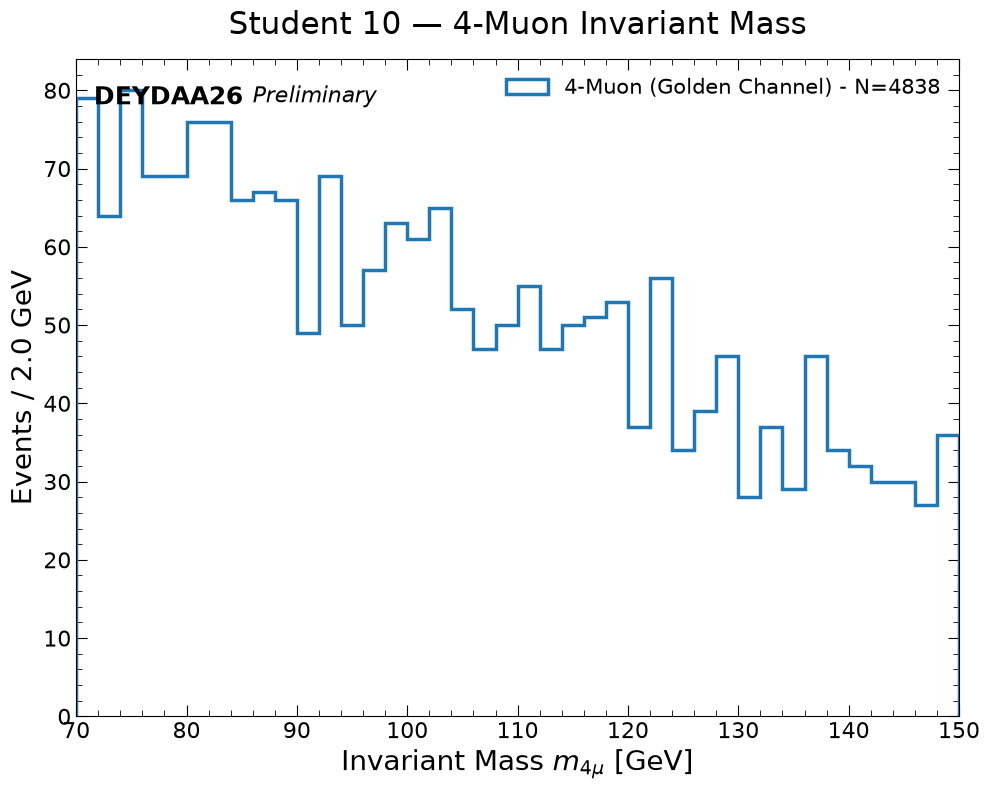

In [80]:
import os
import matplotlib.pyplot as plt

# Altın kanal (Higgs ve ZZ bölgesi) için ideal arama aralığı ve çubuk (bin) sayısı
bins = 40
mass_range = (70, 150)

fig, ax = plt.subplots(figsize=(10, 8))

# 4 Müonlu sistemin kütle histogramını çizdiriyoruz
ax.hist(
    mass_4mu_final,
    bins=bins,
    range=mass_range,
    histtype="step",
    linewidth=2.5,
    color="tab:blue",
    label=f"4-Muon (Golden Channel) - N={len(mass_4mu_final)}"
)

# Eksen ve Etiket Ayarları
ax.set_xlim(*mass_range)
ax.set_ylim(bottom=0)

bin_width = (mass_range[1] - mass_range[0]) / bins
ax.set_xlabel(r"Invariant Mass $m_{4\mu}$ [GeV]", fontsize=20)
ax.set_ylabel(f"Events / {bin_width:.1f} GeV", fontsize=20)

ax.set_title(
    f"Student {STUDENT_NUMBER} — 4-Muon Invariant Mass",
    fontsize=22,
    pad=18
)

# ROOT benzeri kenar çizgileri (CMS stili)
ax.tick_params(axis="both", which="major", direction="in", top=True, right=True, length=8, labelsize=16)
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True, length=4)

ax.text(0.02, 0.96, "DEYDAA26", transform=ax.transAxes, ha="left", va="top", fontsize=18, fontweight="bold")
ax.text(0.20, 0.96, "Preliminary", transform=ax.transAxes, ha="left", va="top", fontsize=16, style="italic")

ax.legend(frameon=False, loc="upper right", fontsize=15)

plt.tight_layout()

# --- GRAFİĞİ KAYDETME ADIMI (Hata Düzeltilmiş Hali) ---
# İşletim sisteminden ana dizinini bularak dosyayı zorla kendi klasörüne yönlendiriyoruz
save_path = os.path.expanduser("~/deydaa_Zmumu/Altin_Kanal_4Muon_Kutlesi.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Grafik başarıyla şu konuma kaydedildi: {save_path}")

plt.show()

In [81]:
import os
import numpy as np

# Dosyanın kaydedileceği tam yol (Kendi klasörün)
csv_path = os.path.expanduser("~/deydaa_Zmumu/Altin_Kanal_Kutleleri.csv")

# mass_4mu_final dizisini CSV formatında dışarı aktarıyoruz
np.savetxt(
    csv_path, 
    mass_4mu_final, 
    delimiter=",", 
    header="mass_4mu_GeV", 
    comments="",  # Başlığın başına # işareti koymasını engeller
    fmt="%.4f"    # Virgülden sonra 4 basamak hassasiyetle kaydeder
)

print(f"4 müon kütle verileri başarıyla kaydedildi:\n{csv_path}")

4 müon kütle verileri başarıyla kaydedildi:
/grid/users/deydaa/deydaa10/deydaa_Zmumu/Altin_Kanal_Kutleleri.csv
